---
title: "Serie temporal"
format:
  html:
    code-fold: false
---

In [1]:
#| echo: false
import pandas as pd
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_arch

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_parquet('../data/logs.parquet')

Las series temporales son un conjunto de observaciones sobre un campo, obtenidas
a intervalos regulares y ordenadas cronológicamente para su correcta interpretación. En este
caso, recogen el número de interacciones cada día en la aplicación web.
El análisis de series temporales aplicado a logs nos proporciona información para la toma
de decisiones. Es posible estudiar los días con más solicitudes, identificar patrones de tráfico,
como picos de actividad o la bajada de la actividad los fines de semana.

## Descomposición Serie Temporal
Se aplicarán técnicas de descomposición de series temporales para estudiar los diferentes
componentes de la misma, los cuales se detallan a continuación:

- **Tendencia:** Existe una tendencia cuando se observa que los datos aumentan o decrecen a lo largo del tiempo. Si la serie se mantiene constante concluimos que no tiene
tendencia.

- **Estacionalidad:** Hay un patrón estacional cuando existe una perioricidad en los datos
dentro de un período (diario, semanal …).

- **Residuo:** Representa lo que no se puede explicar por la tendencia ni la estacionalidad,
es el ruido impredecible de la serie.

Se usa un modelo aditivo para descomponer la serie debido a que la estacionalidad es constante
y no hay grandes oscilaciones:
$$
    Y_t = T_t + S_t + R_t
$$
siendo $T_t$ la tendencia, $S_t$ la componente estacional, y $R_t$ el ruido, donde la suma de todas las componentes da lugar a la serie observada $Y_t$.

Para obtener la serie temporal agrupamos por dia y obtenemos el número de eventos por dia para saber la actividad de la página.
A la hora de hacer la descomposición indicamos una estacionalidad de 7 periodos que corresponden a los dias de la semana.

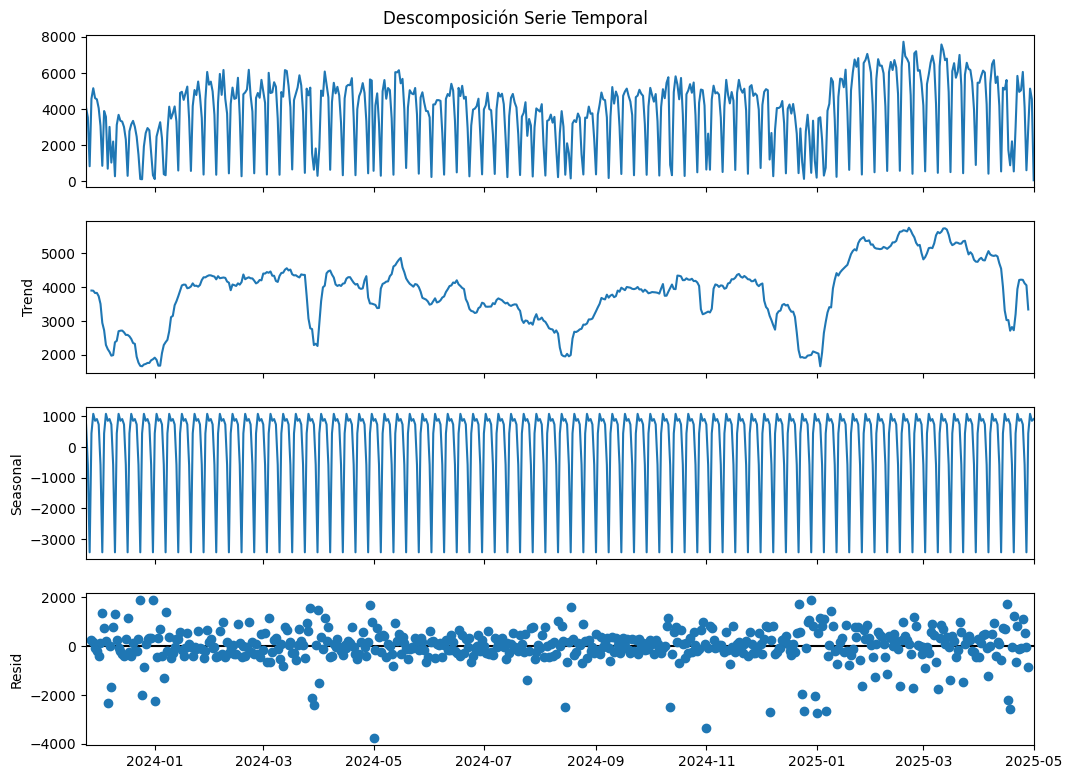

In [2]:
serie_temporal = df.resample('D', on='Fecha').size()
descomposicion = seasonal_decompose(serie_temporal, model='additive', period=7)
fig = descomposicion.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Descomposición Serie Temporal', y=1)
plt.show()

El gráfico de la tendencia muestra cómo evolucionan las interacciones diarias de la web a lo
largo del tiempo, suavizando los efectos estacionales y el ruido. Pueden distinguirse distintos
patrones distinguibles entre sí:

En el primer bloque se observa cómo disminuye la actividad coincidiendo con las vacaciones navideñas. Posteriormente, la tendencia muestra que se incrementa hasta alcanzar un
nivel estable que se mantiene durante varios meses, con pequeñas variaciones.

Sin embargo, hay dos caídas que se aprecian claramente, durante los meses de verano y,
posteriormente, durante el siguiente invierno. Estos descensos son normales ya que se corresponden con períodos vacacionales. Finalmente, a principios de 2025 se registra un aumento
considerable del tráfico en la aplicación, que supera claramente la media de los meses anteriores.

La serie muestra un claro patrón estacional donde cada ciclo se corresponde a una semana,
habiendo picos más altos durante los días laborales (lunes a viernes) y caídas durante los fines
de semana.

En la gráfica de los residuos, la mayoría de los puntos están distribuidos alrededor del 0, lo
cual nos indica que la tendencia y estacionalidad representan la estructura general de la serie.

Sin embargo, al final de la serie se aprecia más dispersión, lo que podría indicar que hay un
poco de heterocedasticidad. Esto será analizado más adelante.


## Test Dickey-Fuller aumentada


Esta prueba sirve para concluir si una serie temporal es estacionaria.

In [3]:
def test_adf(serie):  
    resultado_adf = adfuller(serie, autolag='AIC')
    print(f'ADF Statistic: {resultado_adf[0]:.4f}')
    print(f'p-value: {resultado_adf[1]:.4f}')
    print('Critical Values:')
    for key, value in resultado_adf[4].items():
        print(f'\t{key}: {value:.4f}')

    if resultado_adf[0] < resultado_adf[4]["5%"]:
        print(f"CONCLUSION: p-valor ({resultado_adf[1]:.4f}) <= 0.05 -> Rechazamos H0.")
        print("La serie es ESTACIONARIA.")
    else:
        print(f"CONCLUSION: p-valor ({resultado_adf[1]:.4f}) > 0.05 -> No podemos rechazar H0.")
        print("La serie NO ESTACIONARIA.")

In [4]:
test_adf(serie_temporal)

ADF Statistic: -3.0329
p-value: 0.0319
Critical Values:
	1%: -3.4433
	5%: -2.8672
	10%: -2.5698
CONCLUSION: p-valor (0.0319) <= 0.05 -> Rechazamos H0.
La serie es ESTACIONARIA.


Podemos concluir que la serie es estacionaria, y tiene las siguientes implicaciones:

- La **media** se mantiene en el tiempo.
- La **varianza** es constante, es decir, finalmente tiene homocedasticidad, no heterocedasticidad como podríamos pensar en un primer momento.
- La **autocorrelación** es constante.

## Autocorrelación

La autocorrelación es una medida estadística que evalúa el grado de dependencia lineal entre los valores de una serie temporal y sus propios valores en momentos anteriores. Es decir,
indica en qué medida el valor actual de la serie está relacionado con sus valores pasados. Esta
propiedad es especialmente relevante en el análisis de series temporales, ya que permite identificar patrones repetitivos, como estacionalidad o ciclos, y es fundamental para la selección
de modelos predictivos como ARIMA o SARIMA

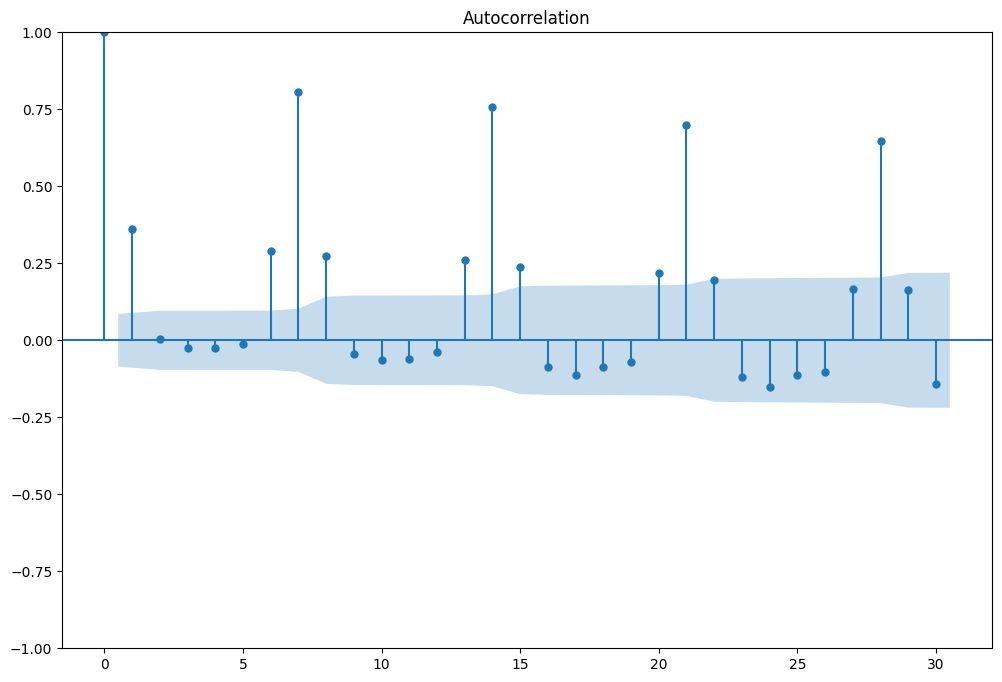

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
plot_acf(serie_temporal, lags=30, ax=ax)   
plt.show()

La gráfica de autocorrelación muestra picos positivos recurrentes cada siete días, indicando
una clara estacionalidad semanal. Estos picos, presentes en los desfases semanales, disminuyen
gradualmente en magnitud conforme aumentan los desfases. Este patrón se debe a que los
domingos no hay actividad, lo que crea una regularidad periódica evidente.

## Comparativa de modelos ARIMA y SARIMA

Los modelos ARIMA y SARIMA son técnicas usadas para predicciones en series temporales. Ambos modelos identifican y descubren patrones.

El **modelo ARIMA** se usa para series temporales que pueden ser convertidas en estacionarias con diferenciación, capturando componentes autorregresivos y de media móvil. Sin
embargo, cuando la serie presenta un comportamiento estacional (patrones que se repiten en
el tiempo), el **modelo SARIMA** es más efectivo, ya que incluye parámetros adicionales para
modelar estos ciclos.

Los parámetros de cada modelo son los siguientes:

- **ARIMA(p, d, q):**
    - **p=1:** *Autoregressive (AR)*. Utiliza un valor pasado (lag) para predecir el actual. El
modelo asume que el valor actual depende del anterior.
    - **d=0:** *Differencing*. No se aplica diferenciación. Se asume que la serie ya es estacionaria (sin tendencia).
    - **q=1:** *Moving Average (MA)*. Utiliza un error pasado (residuo) para ajustar la predicción actual.

- **SARIMA(p, d, q)(P, D, Q, s)**
    - **P=1:** *Seasonal AR (SAR)*. El valor actual depende del valor estacional anterior.
    - **D=1:** *Seasonal Differencing*. Se aplica diferenciación estacional.
    - **Q=1:** *Seasonal MA (SMA)*. Se usa el error de hace un ciclo estacional.
    - **s=7:** *Seasonal Period*. El patrón estacional se repite cada 7 períodos. Esto indica
estacionalidad semanal.


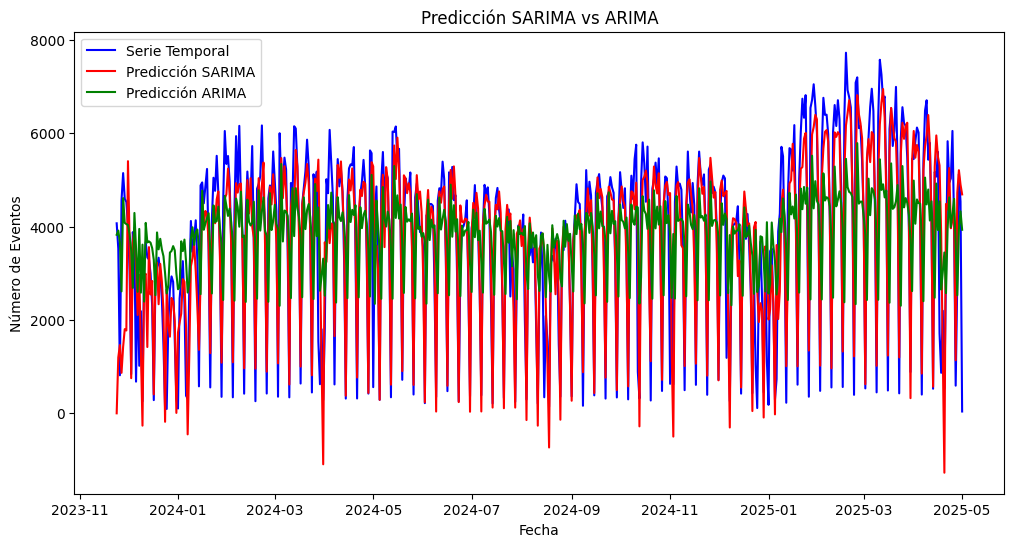

In [ ]:
modelo_sarima = SARIMAX(serie_temporal, order=(1, 0, 1), seasonal_order=(1, 1, 1, 7))
modelo_arima = ARIMA(serie_temporal, order=(1, 0, 1))
arima_fit = modelo_arima.fit().predict()
sarima_fit = modelo_sarima.fit().predict()

plt.figure(figsize=(12, 6))
plt.plot(serie_temporal, label='Serie Temporal', color='blue')
plt.plot(sarima_fit, label='Predicción SARIMA', color='red')
plt.plot(arima_fit, label='Predicción ARIMA', color='green')
plt.title('Predicción SARIMA vs ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.legend()
plt.show()


Se observa a simple vista que SARIMA se ajusta bastante mejor a la serie temporal, ya
que incorpora componentes estacionales que capturan de manera más precisa los patrones
repetitivos presentes en los datos.

## Predicción con SARIMA

Con el modelo calculado anteriormente con SARIMA podemos calcular, por ejemplo, los
valores para las próximas 3 semanas usando la función forecast(steps=21).

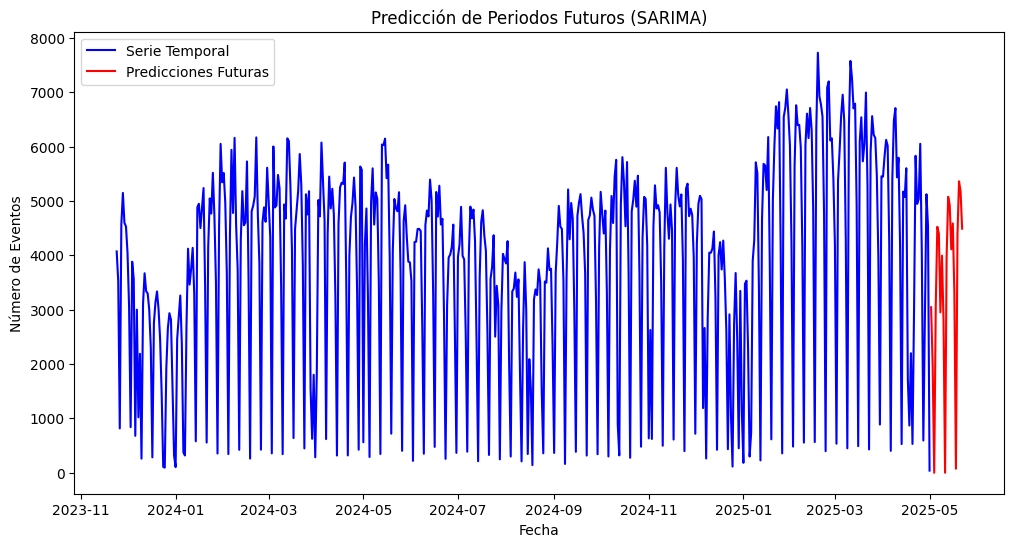

In [14]:
modelo_sarima = SARIMAX(serie_temporal, order=(1, 0, 1), seasonal_order=(1, 1, 1, 7))
sarima_fit = modelo_sarima.fit()

predicciones_futuras = sarima_fit.forecast(steps=21)

predicciones_futuras = np.maximum(predicciones_futuras, 0)

plt.figure(figsize=(12, 6))
plt.plot(serie_temporal, label='Serie Temporal', color='blue')
plt.plot(predicciones_futuras, label='Predicciones Futuras', color='red')
plt.title('Predicción de Periodos Futuros (SARIMA)')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos') 
plt.legend()
plt.show()